# Analysis of Template Count Influence

This notebook investigates how the **number of generated partial templates** affects the registration performance.
The goal is to evaluate whether increasing the number of viewpoint-specific templates leads to improved robustness
and accuracy of the initial pose estimation.

For each object and configuration, statistical metrics such as **fitness**, **inlier RMSE**, **translation** and **rotation errors**
are aggregated across different template counts. Visual plots and summary tables highlight the relationship between
template diversity and the achieved registration quality.

This analysis complements the final experiment by providing deeper insights into the trade-off between **computational cost**
and **pose estimation accuracy** when varying the number of templates.


In [1]:
apple_dir = "../results/evaluate_template_counts_apple/summary_dirs.csv"
banana_dir = "../results/evaluate_template_counts_banana/summary_dirs.csv"

In [2]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter


def add_elev_count(df: pd.DataFrame, *, dir_col="dir", out_col="elev_count"):
    def parse_elevations(s: str):
        s = str(s)
        m = re.search(r"el([a-zA-Z0-9_,\-]+)", s)
        if not m:
            return []
        seg = re.split(r"_az", m.group(1))[0]
        parts = re.split(r"[_,]", seg)
        vals = set()
        for p in parts:
            p = p.strip()
            if not p:
                continue
            m_pm = re.fullmatch(r"pm(\d+)", p)
            if m_pm:
                d = int(m_pm.group(1));
                vals.update([d, -d]);
                continue
            if re.fullmatch(r"-?\d+", p):
                vals.add(int(p))
        return sorted(vals)

    df = df.copy()
    df[out_col] = df[dir_col].apply(lambda s: len(parse_elevations(s)))
    df[out_col] = df[out_col].astype("Int64")
    return df


def load_and_cast(csv_path_str: str) -> pd.DataFrame:
    df = pd.read_csv(Path(csv_path_str))
    # Typen
    for c in ["n_templates", "n_rows", "n_scenes"]:
        df[c] = pd.to_numeric(df[c], errors="coerce").astype("Int64")
    for c in ["mean_best_fitness", "median_best_fitness", "mean_inlier_rmse", "runtime_s"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    # Elevations zählen
    df = add_elev_count(df)
    return df


def plot_fitness_auto(df: pd.DataFrame, *, require_share: float = 0.5):
    if "elev_count" not in df.columns:
        df = add_elev_count(df)
    mask = df["elev_count"].fillna(0).gt(0)
    if mask.mean() >= require_share:
        d = (df[mask].groupby(["n_templates", "elev_count"], as_index=False)
             .agg(mean_best_fitness=("mean_best_fitness", "mean")))
        d = d.sort_values(["n_templates", "elev_count"])
        groups = sorted(d["elev_count"].unique())
        markers = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*"]
        fig, ax = plt.subplots(figsize=(7.2, 4.4))
        for i, g in enumerate(groups):
            sub = d[d["elev_count"] == g].sort_values("n_templates")
            ax.plot(sub["n_templates"], sub["mean_best_fitness"],
                    marker=markers[i % len(markers)],
                    linewidth=1.3, markersize=5,
                    label=f"{int(g)} Elevation" + ("en" if int(g) != 1 else ""))
        xticks = np.sort(df["n_templates"].dropna().unique())
        ax.set_xticks(xticks)
        ax.set_xlabel("Anzahl Templates n")
        ax.set_ylabel("Mean Best Fitness")
        ax.set_title("Best-Fitness vs. n – gruppiert nach Anzahl Elevations")
        ax.grid(True, linewidth=0.5, alpha=0.35)
        ax.legend(title="Gruppen", ncol=min(3, len(groups)))
        y = d["mean_best_fitness"].to_numpy()
        if y.size:
            pad = (y.max() - y.min()) * 0.12 if y.max() > y.min() else 0.02
            ax.set_ylim(y.min() - pad, y.max() + pad)
        if xticks.size:
            ax.set_xlim(xticks.min() - 0.6, xticks.max() + 0.6)
        plt.show()
    else:
        d = df.sort_values("n_templates")
        fig, ax = plt.subplots(figsize=(7, 4.2))
        ax.plot(d["n_templates"], d["mean_best_fitness"], marker="o")
        ax.set_xlabel("Anzahl Templates n");
        ax.set_ylabel("Mean Best Fitness")
        ax.set_title("Best-Fitness vs. Anzahl Templates")
        ax.set_xticks(d["n_templates"]);
        ax.grid(True, linewidth=0.5, alpha=0.35)
        plt.show()


def plot_runtime_auto(df: pd.DataFrame, *, require_share: float = 0.5):
    if "elev_count" not in df.columns:
        df = add_elev_count(df)
    mask = df["elev_count"].fillna(0).gt(0)
    if mask.mean() >= require_share:
        d = (df[mask].groupby(["n_templates", "elev_count"], as_index=False)
             .agg(runtime_s=("runtime_s", "mean")))
        d = d.sort_values(["n_templates", "elev_count"])
        groups = sorted(d["elev_count"].unique())
        markers = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*"]
        fig, ax = plt.subplots(figsize=(7.2, 4.2))
        for i, g in enumerate(groups):
            sub = d[d["elev_count"] == g].sort_values("n_templates")
            ax.plot(sub["n_templates"], sub["runtime_s"],
                    marker=markers[i % len(markers)], linewidth=1.3, markersize=5,
                    label=f"{int(g)} Elevation" + ("en" if int(g) != 1 else ""))
        xticks = np.sort(df["n_templates"].dropna().unique())
        ax.set_xticks(xticks)
        ax.set_xlabel("Anzahl Templates n");
        ax.set_ylabel("Laufzeit [s]")
        ax.set_title("Laufzeit vs. n – gruppiert nach Anzahl Elevations")
        ax.grid(True, linewidth=0.5, alpha=0.35);
        ax.legend(title="Gruppen", ncol=min(3, len(groups)))
        y = d["runtime_s"].to_numpy()
        if y.size:
            pad = (y.max() - y.min()) * 0.12 if y.max() > y.min() else 0.2
            ax.set_ylim(max(0, y.min() - pad), y.max() + pad)
        if xticks.size:
            ax.set_xlim(xticks.min() - 0.6, xticks.max() + 0.6)
        plt.show()
    else:
        d = df.sort_values("n_templates")
        fig, ax = plt.subplots(figsize=(7, 4.2))
        ax.plot(d["n_templates"], d["runtime_s"], marker="o")
        ax.set_xlabel("Anzahl Templates n");
        ax.set_ylabel("Laufzeit [s]")
        ax.set_title("Laufzeit vs. Anzahl Templates")
        ax.set_xticks(d["n_templates"]);
        ax.grid(True, linewidth=0.5, alpha=0.35)
        plt.show()


def plot_rmse_auto(df: pd.DataFrame, *, require_share: float = 0.5, auto_mm: bool = True):
    if "elev_count" not in df.columns:
        df = add_elev_count(df)
    mask = df["elev_count"].fillna(0).gt(0)
    if mask.mean() >= require_share:
        d = (df[mask].groupby(["n_templates", "elev_count"], as_index=False)
             .agg(mean_inlier_rmse=("mean_inlier_rmse", "mean")))
        y_raw = d["mean_inlier_rmse"].to_numpy()
        unit, scale = ("mm", 1000.0) if (auto_mm and y_raw.size and float(np.nanmax(y_raw)) < 0.02) else ("m", 1.0)
        d = d.sort_values(["n_templates", "elev_count"])
        groups = sorted(d["elev_count"].unique())
        markers = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*"]
        fig, ax = plt.subplots(figsize=(7.2, 4.2))
        for i, g in enumerate(groups):
            sub = d[d["elev_count"] == g].sort_values("n_templates")
            ax.plot(sub["n_templates"], sub["mean_inlier_rmse"] * scale,
                    marker=markers[i % len(markers)], linewidth=1.3, markersize=5,
                    label=f"{int(g)} Elevation" + ("en" if int(g) != 1 else ""))
        xticks = np.sort(df["n_templates"].dropna().unique())
        ax.set_xticks(xticks)
        ax.set_xlabel("Anzahl Templates n");
        ax.set_ylabel(f"Mean Inlier-RMSE [{unit}]")
        ax.set_title("Inlier-RMSE vs. n – gruppiert nach Anzahl Elevations")
        ax.grid(True, linewidth=0.5, alpha=0.35);
        ax.legend(title="Gruppen", ncol=min(3, len(groups)))
        y = (d["mean_inlier_rmse"] * scale).to_numpy()
        if y.size:
            pad = (y.max() - y.min()) * 0.12 if y.max() > y.min() else 0.02 * (y.max() if y.max() else 1.0)
            ax.set_ylim(y.min() - pad, y.max() + pad)
        if xticks.size:
            ax.set_xlim(xticks.min() - 0.6, xticks.max() + 0.6)
        plt.show()
    else:
        d = df.sort_values("n_templates")
        y = d["mean_inlier_rmse"].to_numpy()
        unit, scale = ("mm", 1000.0) if (auto_mm and y.size and float(np.nanmax(y)) < 0.02) else ("m", 1.0)
        fig, ax = plt.subplots(figsize=(7, 4.2))
        ax.plot(d["n_templates"], y * scale, marker="o")
        ax.set_xlabel("Anzahl Templates n");
        ax.set_ylabel(f"Mean Inlier-RMSE [{unit}]")
        ax.set_title("Inlier-RMSE vs. Anzahl Templates")
        ax.set_xticks(d["n_templates"]);
        ax.grid(True, linewidth=0.5, alpha=0.35)
        plt.show()


def plot_tradeoff_auto(df: pd.DataFrame, *, require_share: float = 0.5, annotate_n: bool = True):
    if "elev_count" not in df.columns:
        df = add_elev_count(df)
    mask = df["elev_count"].fillna(0).gt(0)
    d = df.sort_values(["elev_count", "n_templates"]).copy()
    if mask.mean() >= require_share:
        groups = sorted(d.loc[mask, "elev_count"].unique())
        markers = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*"]
        fig, ax = plt.subplots(figsize=(7.2, 4.2))
        for i, g in enumerate(groups):
            sub = d[(d["elev_count"] == g)]
            ax.scatter(sub["runtime_s"], sub["mean_best_fitness"],
                       s=60, alpha=0.9, marker=markers[i % len(markers)],
                       label=f"{int(g)} Elevation" + ("en" if int(g) != 1 else ""))
            if annotate_n:
                for _, row in sub.iterrows():
                    ax.annotate(str(int(row["n_templates"])),
                                xy=(row["runtime_s"], row["mean_best_fitness"]),
                                xytext=(3, 3), textcoords="offset points", fontsize=9, alpha=0.9)
        ax.set_title("Trade-off: Fitness vs. Laufzeit – gruppiert nach Anzahl Elevations")
        ax.legend(title="Gruppen", ncol=min(3, len(groups)))
    else:
        fig, ax = plt.subplots(figsize=(7, 4.2))
        ax.scatter(d["runtime_s"], d["mean_best_fitness"], s=60, alpha=0.9)
        if annotate_n:
            for _, row in d.iterrows():
                ax.annotate(str(int(row["n_templates"])),
                            xy=(row["runtime_s"], row["mean_best_fitness"]),
                            xytext=(3, 3), textcoords="offset points", fontsize=9, alpha=0.9)
        ax.set_title("Trade-off: Fitness vs. Laufzeit")

    ax.set_xlabel("Laufzeit [s] (niedriger ist besser)")
    ax.set_ylabel("Mean Best Fitness (höher ist besser)")
    ax.grid(True, linewidth=0.5, alpha=0.35)
    x = d["runtime_s"].to_numpy();
    y = d["mean_best_fitness"].to_numpy()
    if x.size > 1:
        xpad = (x.max() - x.min()) * 0.08
        ypad = (y.max() - y.min()) * 0.10 if y.max() > y.min() else 0.02
        ax.set_xlim(x.min() - xpad, x.max() + xpad)
        ax.set_ylim(y.min() - ypad, y.max() + ypad)
    plt.show()


def plot_analysis(csv_path_str: str):
    df = load_and_cast(csv_path_str)
    # Optional kurzer Check
    # print(df[["dir","n_templates","elev_count"]].head())

    plot_fitness_auto(df)
    plot_runtime_auto(df)
    plot_rmse_auto(df)
    plot_tradeoff_auto(df)


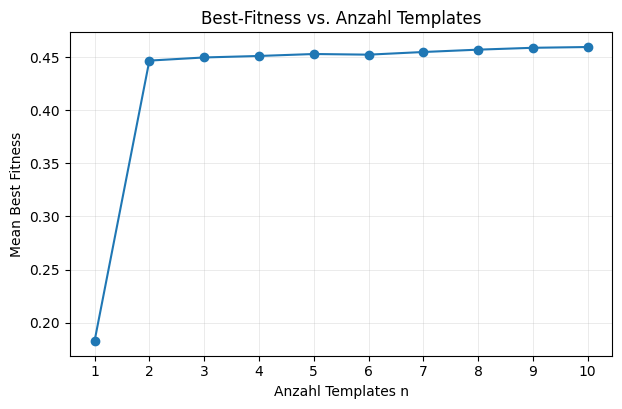

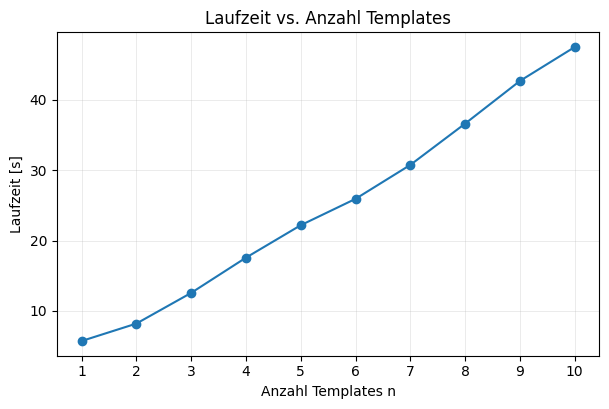

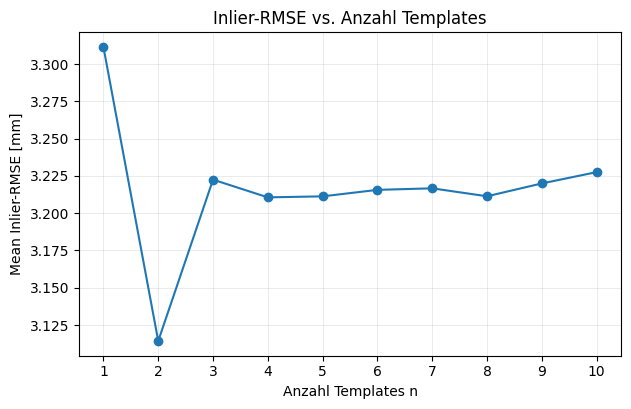

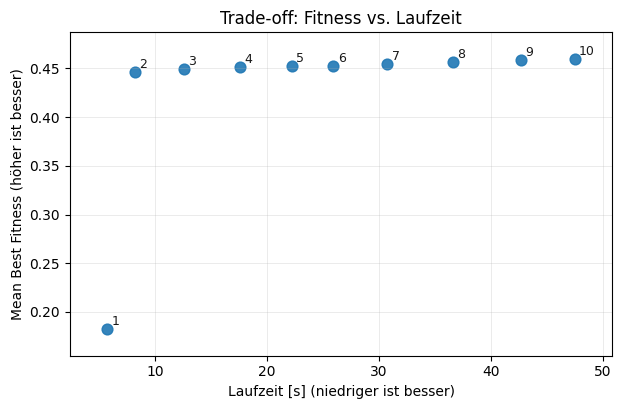

In [3]:
plot_analysis(apple_dir)

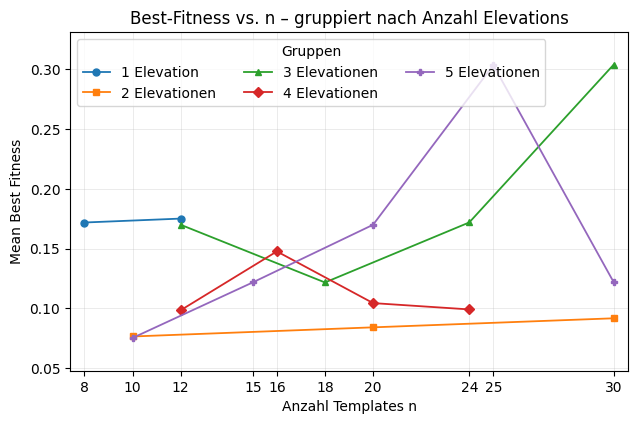

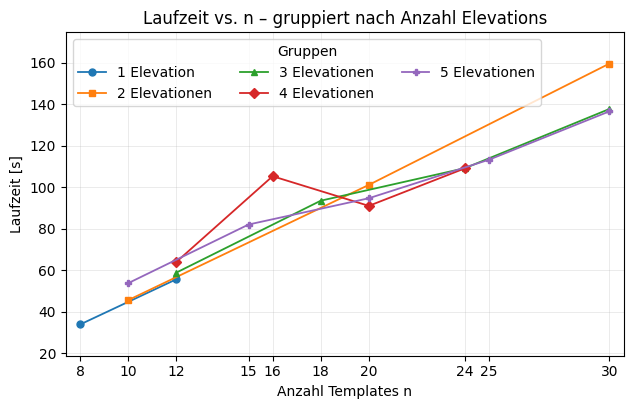

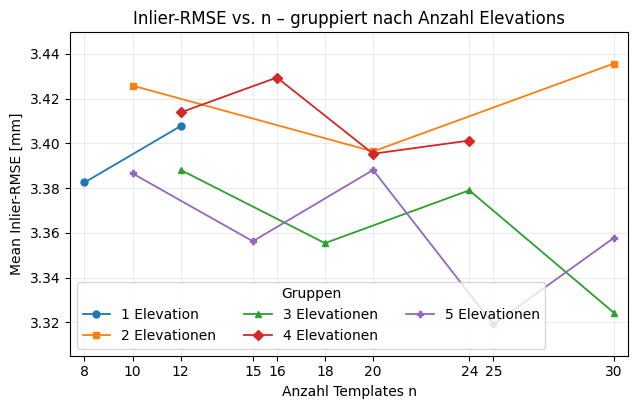

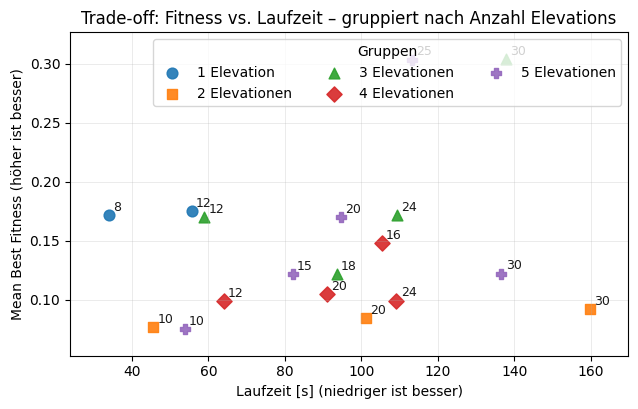

In [4]:
plot_analysis(banana_dir)